# Disentanglement Analysis Demo

This notebook demonstrates how to use the refactored `disentanglement.py` library for analyzing disentanglement in quantum systems.
The library follows SOLID principles, separating Hamiltonian generation, analysis, and visualization.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Ensure the local module is importable
sys.path.append(os.getcwd())

import disentanglement

%matplotlib inline

## 1. Hamiltonian Generation

We can generate different types of Hamiltonians using the `HamiltonianGenerator` subclasses.
Available generators:
- `MixedFieldIsingHamiltonian`
- `SinglePixelHamiltonian`
- `TwoPixelHamiltonian`
- `CentralSpinHamiltonian`

In [2]:
# Example: Generate a Central Spin Hamiltonian
N_star = 8
generator = disentanglement.CentralSpinHamiltonian(N_star=N_star, Jx=1.0, Jz=1.0)
H = generator.generate()

print(f"Generated Hamiltonian of size: {H.shape}")

Generated Hamiltonian of size: (512, 512)


## 2. Time Evolution

We generate the unitary time evolution operator $U = e^{-iHt}$.
Note: For disentanglement analysis, we often look at backward evolution (negative time).

In [3]:
t = -10.0
U = disentanglement.generate_time_evolution_operator(H, t)
print(f"Unitary operator shape: {U.shape}")

Unitary operator shape: (512, 512)


## 3. Disentanglement Analysis

The `DisentanglementAnalyzer` class performs the diagonalization of sub-block products to find the optimal basis.

In [4]:
analyzer = disentanglement.DisentanglementAnalyzer(U)
analyzer.diagonalize_sublocks_product(verbose=True)
analyzer.get_initial_qubit_states_from_eigenvalues()

Diagonalizing W0 and W1...
Elapsed time: 0.4756045341491699 seconds


## 4. Visualization

We use `DisentanglementVisualizer` to plot the results.

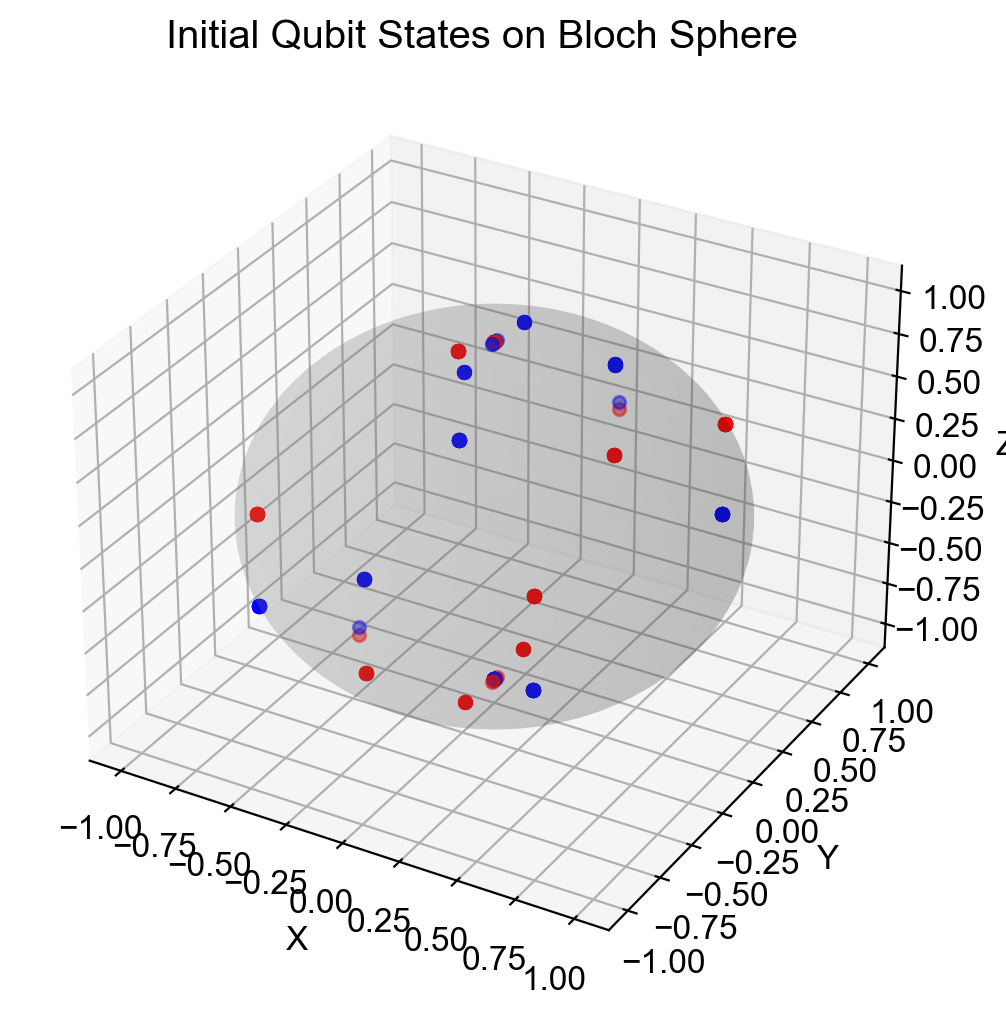

In [5]:
visualizer = disentanglement.DisentanglementVisualizer(analyzer)

# 1. Plot states on Bloch Sphere
visualizer.plot_bloch_sphere()

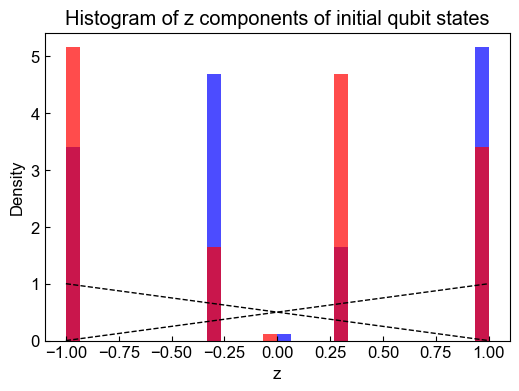

In [6]:
# 2. Plot Z-component histograms
visualizer.plot_z_histograms()